# Understanding the exclusion regions

**Paper element.** None directly. This is background on why the excluded region
has the shape it does; its transit and reach maps are not reproduced in the paper.

**Private.** Pedagogical companion to
[`01_limit_contour.ipynb`](01_limit_contour.ipynb) — it explains *why* the
excluded region has the shape it does, edge by edge. Nothing here feeds the
limit. Mode-aware via `MODE_NUMBER` (same inputs as notebook 01); the scalings
below are mode-independent.

**Dark matter fraction.** This notebook opens file A of the release, which
carries one hypothesis: $f_\mathrm{DM}$ = 1 with atmospheric attenuation, the
same plane notebook 01 quotes its limits on. The `/halo` maps are the exception
— they are stored once at the build-side baseline $f_\mathrm{DM}$ = 0.1 and
have no fraction axis, so their transit counts are a factor of 10 below the
`/results` ones. That is fine here: the maps are pedagogical and the region's
*shape* is independent of $f_\mathrm{DM}$ up to a flux rescaling.

In [1]:
# ===== CONFIG: which sensor mode this notebook analyses =====
MODE_NUMBER = 1   # 1, 2, or 3

%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, units
from luhdm import release
# File A of the released pair: f_DM = 1 with atmospheric attenuation. The
# internal full-lambda cube stays on luhdm.release.DEFAULT_PATH for the
# paper-figure scripts.
rel = release.open_release("../release/luhdm_datarelease_v8_A_f1_atm.h5")

R_eff = config.R_EFF             # 260 um
Q_THRESH = config.Q_THRESH       # GeV (1 TeV analysis threshold)
T_TOTAL = config.T_EXPOSURE      # dataset live-time (single source of truth);
                                  # env-overridable via LUHDM_T_EXPOSURE,
                                  # currently the night-selection exposure (219.66 h)
CONFIDENCE = 0.95
M_PLANCK = 1.22e19               # GeV
F_DM = 1.0                       # this file's only hypothesis; the loader's
                                 # fallback (0.1) is not on its axis
M_WALL = Q_THRESH / config.VESC  # kinematic wall [GeV]
M_CUT = next(float(v) for k, v in rel.attrs.items()
             if k.startswith("m_cut_") and k.endswith("_gev"))
N_REQ = float(rel.attrs["m_cut_n_transits_required"])
B_CAP_CUT = float(rel.attrs["m_cut_b_cap_m"])   # aperture of the flux cut

# the seven planned mediator ranges, largest first. The family is ordered in
# lambda, so it gets a sequential blue-to-green ramp (truncated viridis:
# monotone lightness survives black-and-white printing and is colorblind-safe,
# and it contains no red, which is reserved for the events / 95% contour).
_TAGS = ["2m", "2cm", "2mm", "200um", "20um", "10um", "2um"]
_LAMBS = [2.0, 2e-2, 2e-3, 2e-4, 2e-5, 1e-5, 2e-6]
_RAMP = plt.cm.viridis(np.linspace(0.02, 0.78, len(_TAGS)))
LAMBDAS = list(zip(_TAGS, _LAMBS, [tuple(c) for c in _RAMP]))
HIDE = {"2um"}                   # loaded and exported, but not drawn
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si}"


def mphi_label(lamb_m, unit="eV"):
    # mediator mass m_phi = hbar c / lambda
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def range_legend(lamb_m):
    # legend entry: range and the corresponding mediator mass (in eV)
    return lamb_label(lamb_m).split(" = $")[0] + ", " + mphi_label(lamb_m)


# SI-prefix milestones on a DM-mass axis (masses in GeV; names in eV prefixes)
MASS_MILESTONES = [(1e6, "PeV"), (1e9, "EeV"), (1e12, "ZeV"), (1e15, "YeV")]

def mark_mass_milestones(ax, m_lo, m_hi):
    import matplotlib.patheffects as _pe
    for m_gev, name in MASS_MILESTONES:
        if m_lo < m_gev < m_hi:
            ax.axvline(m_gev, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            txt = ax.text(m_gev, 0.015, f" {name}", color="#555555",
                          fontsize=9, ha="left", va="bottom", rotation=90,
                          transform=ax.get_xaxis_transform())
            txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                                  _pe.Normal()])


import os as _os
for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number
    # prefix, stamped with the data-release version that produced it so
    # a figure always names its cube
    fig.text(0.995, 0.004, f"POLONAISE UHDM data release {rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um   f_X = {config.F_X}")

N_n = 1.07e+20   q_th = 1000 GeV   R_eff = 260 um   f_X = 0.1


In [2]:
# Observed impulse candidates for this mode (GeV), from the data release.
# Kept only for label counts; nothing here feeds the maps below.
EVENTS = rel.events(MODE_NUMBER)
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [12790.7  6905.1  3509.6  3252.4  2862.   2033.7  1729.4  1520.7]


In [3]:
# The two exclusion planes overlaid on the maps below: the massless (Coulomb)
# scan and the finite reference-range (200 um) scan, sliced from the data release.
P_ML = rel.mass_plane("extremeness", MODE_NUMBER, "massless", f_dm=F_DM)
P_REF = rel.mass_plane("extremeness", MODE_NUMBER, "200um", f_dm=F_DM)
print(f"kinematic wall {M_WALL:.3g} GeV | flux cut {M_CUT:.3g} GeV "
      f"(N_req = {N_REQ:g} transits within {B_CAP_CUT:g} m)")

kinematic wall 5.51e+05 GeV | flux cut 6.11e+14 GeV (N_req = 3 transits within 0.1 m)


## Understanding the edges

*Everything in this section is pedagogical; none of it feeds the limit.* Every
edge of the excluded region has a one-line explanation (scalings at fixed
exposure):

- **Left edge (kinematic wall).** Below
  $m = q_\text{th}/v_\text{esc} = 5.51\times10^{5}$ GeV even an
  escape-velocity particle cannot deliver the threshold kick, at any coupling
  ($q_\text{th}$ = 1 TeV/$c$, $v_\text{esc} = 1.8\times10^{-3}$). This is the
  left edge of every region in notebook 01, and it is hard: the first excluded
  grid mass, $6.85\times10^{5}$ GeV, is the first grid point above it.
- **Bottom edge (statistics floor).** The smallest coupling with $\mu \gtrsim 3$
  expected events. The rate scales as $\alpha^2 n_\text{DM} \propto \alpha^2/m$,
  so the floor rises as $\alpha_\text{min} \propto \sqrt{m}$. Ranges with
  $\lambda \gtrsim$ mm share the same floor (Coulomb regime); shorter ranges pay
  the momentum-cap penalty, $\tilde q_\text{max} = K_1(\xi)$.
- **Top edge (atmospheric ceiling), where there is one.** Stopping power also
  scales as $\alpha^2/m$: above the ceiling particles arrive below threshold
  speed, so the ceiling rises $\propto \sqrt{m}$ (up to a Coulomb log). It
  meets the top of the scanned coupling grid part way along the massless
  contour, and beyond that the band is open at the top: an edge drawn at
  $\alpha_n = 1$ is where the scan stopped, not where the physics closed.
- **Right edge, finite range (reach saturation).** Once the impact parameters
  needed for a kick exceed $\lambda$, the reach grows only as
  $\lambda\ln\alpha$, the cross section saturates at $\sim\lambda^2$, and the
  falling number density $1/m$ wins: each factor of 10 in $\lambda$ buys roughly
  a factor of 100 in mass reach. No finite range reaches the Planck mass. This
  edge is in the surface itself.
- **Right edge, massless (the flux cut).** An exactly massless mediator has
  Coulomb reach $\propto \alpha$, and this release does **not** truncate the
  impact-parameter integral, so nothing in the surface closes the band: the
  massless contour runs to the Planck mass. What closes it is a statement made
  *after* the calculation — that the halo must deliver at least
  $N_\text{req} = 3$ particles within 10 cm of the sensor during the exposure —
  giving $m_\text{cut} = 6.11\times10^{14}$ GeV at $f_\mathrm{DM}$ = 1. The
  maps below are where that statement can be read off: it is the $N_t$ contour
  of the *aperture*, not of the reach.

The maps below make these statements visible for the reference range.

### Transit-count and reach maps up to the Planck mass

These maps are supplemental backup material; they are sliced from the `/halo`
group of the data release.

**Top row:** color is $\log_{10} N_t$, the expected number of particles passing
within $\pi b_\text{max}^2$ during the exposure (halo flux, no attenuation;
the atmosphere only matters near the low-mass ceiling). White contours mark
decades of $N_t$ (the $N_t = 1$ line is drawn heavier); red: the 95% exclusion
contour from the scan. The
finite-range $N_t = 1$ boundary is a near-vertical wall (saturating reach);
the massless mediator's boundary follows a $\sqrt{m}$ diagonal and keeps going,
because with no cap on the impact-parameter integral the reach keeps growing
with coupling. Nothing in these maps stands it up into a wall — that is the
point, and it is why the release states the flux cut separately.

**Bottom row:** the flux-averaged threshold reach
$b_\text{max} = \sqrt{\langle b^2 \rangle}$ in meters, with contours at
everyday length scales and the same red 95% exclusion contour overlaid, so
the reach along the sensitivity boundary can be read off directly. This is the aperture that converts flux into transits,
$N_t = \Phi \cdot \pi b_\text{max}^2 \cdot T$: for the massless mediator the
*formal* reach at large coupling is macroscopic
($b_\text{max} = 2\alpha/(q_\text{th} v)$), and this release does not cap it, so
the massless reach map runs off to macroscopic values at strong coupling; the
finite-range reach saturates near $R_\text{eff} + \mathcal{O}(10)\lambda$,
which is why its $N_t = 1$ wall is real.

**This is what the flux cut is for.** Rather than truncating the integral, the
release evaluates the same arithmetic once, at a fixed 10 cm aperture, and
states the mass where it runs out:
$N(m) = f_\mathrm{DM}\,\rho_0\,\langle v\rangle\,\pi b_\text{cap}^2\,T / m$,
so
$m_\text{cut} = f_\mathrm{DM}\,\rho_0\,\langle v\rangle\,\pi b_\text{cap}^2\,T
/ N_\text{req} \approx 1.8\times10^{14}\ \text{GeV} \times
(f_\mathrm{DM}/0.1)\,(b_\text{cap}/10\,\text{cm})^2\,(T/220\,\text{h})\,
(1/N_\text{req})$, evaluated at the 219.66 h analysis live-time. At
$N_\text{req} = 3$ — **an assumption of the release, not a measurement** — that
is $6.11\times10^{13}$ GeV at $f_\mathrm{DM}$ = 0.1 and $6.11\times10^{14}$ GeV
at $f_\mathrm{DM}$ = 1. The density is the *species* density
$f_\mathrm{DM}\rho_0$, not the total: the maps here are sliced from `/halo`,
which is stored at the baseline $f_\mathrm{DM}$ = 0.1 (multiply by
$f_\mathrm{DM}/0.1$ for another fraction).


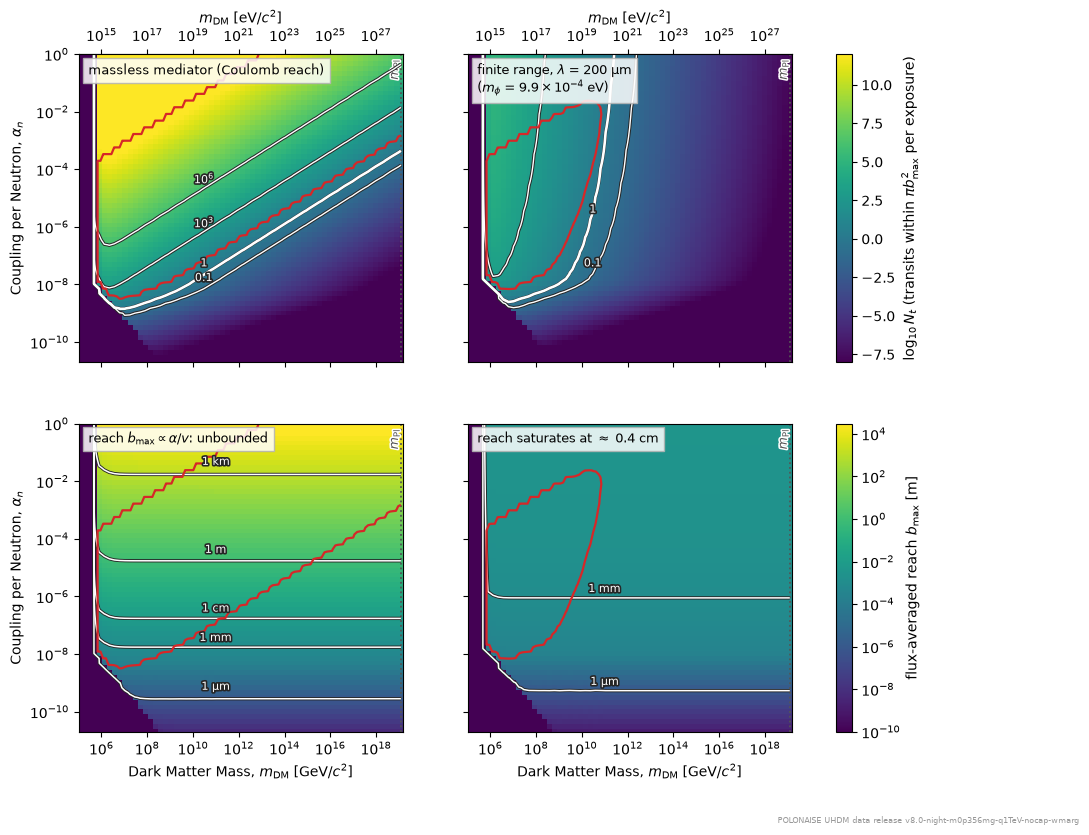

In [4]:
# transit-count and reach maps, sliced from the /halo group of the data release
ms_map, al_map = rel.axes_halo.mass_gev, rel.axes_halo.alpha_n
NT_ML_MAP = rel.mass_plane("n_transit", lam="massless", group="halo")
B_ML_MAP = rel.mass_plane("bmax", lam="massless", group="halo")
NT_FR_MAP = rel.mass_plane("n_transit", lam="200um", group="halo")
B_FR_MAP = rel.mass_plane("bmax", lam="200um", group="halo")

import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm, Normalize

def outline(artists):  # keep white lines/labels legible on any viridis shade
    for a in artists:
        a.set_path_effects([pe.Stroke(linewidth=2.4, foreground="0.15"),
                            pe.Normal()])

def label_levels(ax, X_MAP, levels, names, m_ref=1e11):
    # label each level just above its line, mid-plot (the lines are close to
    # horizontal away from the kinematic floor)
    col = np.argmin(np.abs(ms_map - m_ref))
    for lev in levels:
        with np.errstate(divide="ignore"):
            miss = np.abs(np.log10(np.where(X_MAP[:, col] > 0,
                                            X_MAP[:, col], np.nan) / lev))
        if np.nanmin(miss) < 0.3:
            y = al_map[np.nanargmin(miss)]
            txt = ax.text(m_ref, y * 1.5, names[lev], fontsize=8, color="w",
                          ha="center", va="bottom")
            outline([txt])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.8), sharex=True, sharey=True)
norm_nt = Normalize(vmin=-8, vmax=12)
norm_b = LogNorm(vmin=1e-10, vmax=3e4)
NT_LEVELS = [0.1, 1.0, 1e3, 1e6]
NT_NAMES = {0.1: "0.1", 1.0: "1", 1e3: "$10^3$", 1e6: "$10^6$"}
B_LEVELS = [1e-6, 1e-3, 1e-2, 1.0, 1e3]
B_NAMES = {1e-6: "1 µm", 1e-3: "1 mm", 1e-2: "1 cm", 1.0: "1 m", 1e3: "1 km"}
titles = ["massless mediator (Coulomb reach)",
          "finite range, " + lamb_label(LAMB_REF) + "\n(" +
          mphi_label(LAMB_REF) + ")"]

for j, (NT_MAP, B_MAP) in enumerate([(NT_ML_MAP, B_ML_MAP),
                                     (NT_FR_MAP, B_FR_MAP)]):
    ax = axes[0, j]
    z = np.log10(np.clip(NT_MAP, 1e-8, 1e12))
    mesh_nt = ax.pcolormesh(ms_map, al_map, z, cmap="viridis", norm=norm_nt,
                            shading="auto")
    cs = ax.contour(ms_map, al_map, NT_MAP, levels=NT_LEVELS, colors="w",
                    linewidths=[1.0 if lev != 1.0 else 1.9
                                for lev in NT_LEVELS])
    outline(getattr(cs, "collections", [cs]))
    label_levels(ax, NT_MAP, NT_LEVELS, NT_NAMES, m_ref=3e10)
    ax.text(0.03, 0.97, titles[j], transform=ax.transAxes, ha="left",
            va="top", fontsize=9, bbox=dict(fc="white", ec="0.7", alpha=0.85))

    ax = axes[1, j]
    mesh_b = ax.pcolormesh(ms_map, al_map, np.clip(B_MAP, 1e-10, None),
                           cmap="viridis", norm=norm_b, shading="auto")
    cs = ax.contour(ms_map, al_map, B_MAP, levels=B_LEVELS, colors="w",
                    linewidths=1.1)
    outline(getattr(cs, "collections", [cs]))
    label_levels(ax, B_MAP, B_LEVELS, B_NAMES)
    _cap = rel.b_constrained_max          # None if the cube is uncapped
    note = ((r"reach $b_{\rm max} \propto \alpha/v$" +
             (rf", capped at {_cap * 100:.0f} cm" if _cap else ": unbounded"))
            if j == 0 else
            rf"reach saturates at $\approx$ {B_MAP.max() * 100:.1f} cm")
    ax.text(0.03, 0.97, note, transform=ax.transAxes, ha="left",
            va="top", fontsize=9, bbox=dict(fc="white", ec="0.7", alpha=0.85))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")

# overlay each column's own 95% exclusion: the massless (Coulomb) scan on the
# massless panels, the finite reference-range scan on the finite-range panels
COL_SCAN = [dict(ms=rel.axes.mass_gev, alphas_n=rel.axes.alpha_n, extremeness=P_ML),
            dict(ms=rel.axes.mass_gev, alphas_n=rel.axes.alpha_n, extremeness=P_REF)]   # j=0 massless, j=1 finite (200um)
for i in (0, 1):
    for j in (0, 1):
        s = COL_SCAN[j]
        if s is None:
            continue
        axes[i, j].contour(s["ms"], s["alphas_n"], s["extremeness"],
                           levels=[CONFIDENCE], colors="#d62728",
                           linewidths=1.6)

# the mass grid stops at the Planck mass: mark that endpoint (label inside)
_m_pl = ms_map[-1]
for ax in axes.ravel():
    ax.axvline(_m_pl, color="#555555", lw=1.3, ls=":", zorder=1)
    _t = ax.text(_m_pl, 0.985, r"$m_{\mathrm{Pl}}$", color="#555555",
                 fontsize=9, ha="right", va="top", rotation=90,
                 zorder=1.5,   # under contour lines: halo must not notch them
                 transform=ax.get_xaxis_transform())
    _t.set_path_effects([pe.Stroke(linewidth=2.2, foreground="w"), pe.Normal()])

for ax in axes[:, 0]:
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
axes[0, 0].set_ylim(al_map[0], 1.0)
for j in (0, 1):
    sec = axes[0, j].secondary_xaxis(
        "top", functions=(lambda x: x * 1e9, lambda x: x / 1e9))
    sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
fig.colorbar(mesh_nt, ax=axes[0, :], label=r"$\log_{10} N_t$ (transits within "
                                           r"$\pi b_{\rm max}^2$ per exposure)")
fig.colorbar(mesh_b, ax=axes[1, :],
             label=r"flux-averaged reach $b_{\rm max}$ [m]")
save_figure(fig, "03_transit_reach_maps", bbox_inches="tight")

## Further reading

- Monteiro et al., PRL 125, 181102 ([arXiv:2007.12067](https://arxiv.org/abs/2007.12067)):
  the massless-mediator behavior (open band, no high-mass endpoint).
- The public tutorial
  [`uhdm_finite_range.ipynb`](https://github.com/tunnell/optimum_interval/blob/master/examples/uhdm_finite_range.ipynb):
  the same seven ranges in vacuum with a five-candidate toy dataset; comparing
  the two shows what the atmosphere does to each channel.
